# Hybrid CNN + ViT for KDRIFT G1 Alignment

- `decenter+-0.095mm,tilt+-0.075deg`
- EDA the training set
- CNN Stem + ViT Hybrid model 
- `MAX_CAP = 6` Normalization
- 64x64 image, 4x4 patch size, 256 tokens (16x16 grids)
- X_f32.npy: Image Normalization .. Let's find out what is the best "Fixed Max" value for ultimate normalization .. some modification.. not -1 to +1 .. 0 to 1 at absolute full normalization
- y_f32.npy: also we need to rescale this ..

In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tqdm import trange, notebook

import matplotlib.pyplot as plt

In [2]:
import matplotlib
import seaborn as sns

sns.reset_defaults()                 # seaborn 스타일 제거
matplotlib.rcParams.update(matplotlib.rcParamsDefault)  # matplotlib 완전 초기화

# Basic Settings for matplotlib
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["mathtext.fontset"] = "stix"
#%matplotlib inline
#matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")  # For export
matplotlib.rcParams["lines.linewidth"] = 2.0

## Browsing the working directories

In [3]:
%pwd

'/app/kdrift/decenter+-0.095,tilt+-0.075/pytorch/notebook'

In [4]:
%ls

cnn-align-v7-fixed-maxcap-Xy-rescaled.ipynb
cnn_maxcap50_positive_only_norm.png
cnn_maxcap50_positive_only_norm_y_rescaled.png
history-hybrid-stemch64-tanh-ntok64-maxcap50-norm.png
history-hybrid-stemch64-tanh-ntok64-maxcap6-y-rescaled.png
hybrid-align-v3a-tahn-stemch64-ntok64-fixed-maxcap-Xy-rescaled.ipynb
hybrid-align-v4-tahn-stemch256-ntok256-fixed-maxcap-Xy-rescaled.ipynb
hybrid-stemch64-tanh-ntok64-maxcap6-y_rescaled.png
lightning_logs/
no-y-rescaled/
vit-align-v1c-ntok64-fixed-maxcap-Xy-rescaled.ipynb
vit_64ntok_maxcap_y_rescaled_both_signs_1c.png
vit_64ntok_maxcap_y_scaled_both_signs_1c.png


In [5]:
data_path = '/app/kdrift/decenter+-0.095,tilt+-0.075/pytorch/data/'

In [6]:
!ls {data_path}

X_f32.npy  y_f32.npy


## Explore the training set

In [7]:
%%time
X = np.load(data_path+'X_f32.npy')
y = np.load(data_path+'y_f32.npy')

CPU times: user 0 ns, sys: 224 ms, total: 224 ms
Wall time: 223 ms


In [8]:
len(y),len(X)

(20000, 20000)

In [9]:
def np_array_info(a):
    print(f"shape     : {a.shape}")
    print(f"dtype     : {a.dtype}")
    print(f"ndim      : {a.ndim}")
    print(f"size      : {a.size}")
    print(f"itemsize  : {a.itemsize} bytes")
    print(f"nbytes    : {a.nbytes / 1024**2:.2f} MB")
    print(f"min / max : {a.min()} / {a.max()}")

In [10]:
np_array_info(X)

shape     : (20000, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 409600000
itemsize  : 4 bytes
nbytes    : 1562.50 MB
min / max : -5.8238911628723145 / 5.863417148590088


In [11]:
np_array_info(y)

shape     : (20000, 6)
dtype     : float32
ndim      : 2
size      : 120000
itemsize  : 4 bytes
nbytes    : 0.46 MB
min / max : -0.0949999988079071 / 0.09499000012874603


In [12]:
for i in range(y.shape[1]):
    print(f"channel {i}: min={y[:, i].min()}, max={y[:, i].max()}")

channel 0: min=-0.0949999988079071, max=0.09499000012874603
channel 1: min=-0.0949999988079071, max=0.09498000144958496
channel 2: min=-0.0949999988079071, max=0.09499000012874603
channel 3: min=-0.07500000298023224, max=0.07498999685049057
channel 4: min=-0.07500000298023224, max=0.07500000298023224
channel 5: min=-0.07498999685049057, max=0.07498999685049057


#### Visualize the training set

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_trainingsample(
    X,
    y,
    selected_index_list,
    pix_min=-6.0,
    pix_max=6.0,
):
    n_samples = len(selected_index_list)
    n_views = X.shape[1]

    fig, axes = plt.subplots(
        n_samples, n_views,
        figsize=(n_views * 2.2, n_samples * 2.2)
    )

    im = None

    for row, idx in enumerate(selected_index_list):
        for j in range(n_views):
            ax = axes[row, j]
            img = X[idx, j, :, :, 0]

            im = ax.imshow(
                img,
                cmap="rainbow",
                vmin=pix_min,
                vmax=pix_max,
                aspect="equal"
            )

            ax.set_xticks([])
            ax.set_yticks([])

            if row == 0:
                ax.set_title(f"image {j}")

            # --- min / max labels (always show actual image stats)
            img_min = img.min()
            img_max = img.max()

            labels = [
                f"min: {img_min:.2f}",
                f"max: {img_max:.2f}",
            ]

            # --- include y only on first column
            if y is not None and j == 0:
                yvals = y[idx]
                labels += [
                    f"y{i}: {val:.3f}" for i, val in enumerate(yvals)
                ]
                ax.set_ylabel(f"idx {idx}")

            handles = [
                plt.Line2D([0], [0], color="none", label=lab)
                for lab in labels
            ]

            ax.legend(
                handles=handles,
                loc="upper left" if j == 0 else "upper right",
                fontsize=8,
                frameon=True,
                borderpad=0.3,
                handlelength=0,
                handletextpad=0
            )

    fig.subplots_adjust(
        bottom=0.12,
        hspace=0.05,
        wspace=0.02
    )

    fig.colorbar(
        im,
        ax=axes,
        orientation="horizontal",
        fraction=0.035,
        pad=0.02,
        label=f"Pixel value (clipped to [{pix_min}, {pix_max}])"
    )

    plt.show()

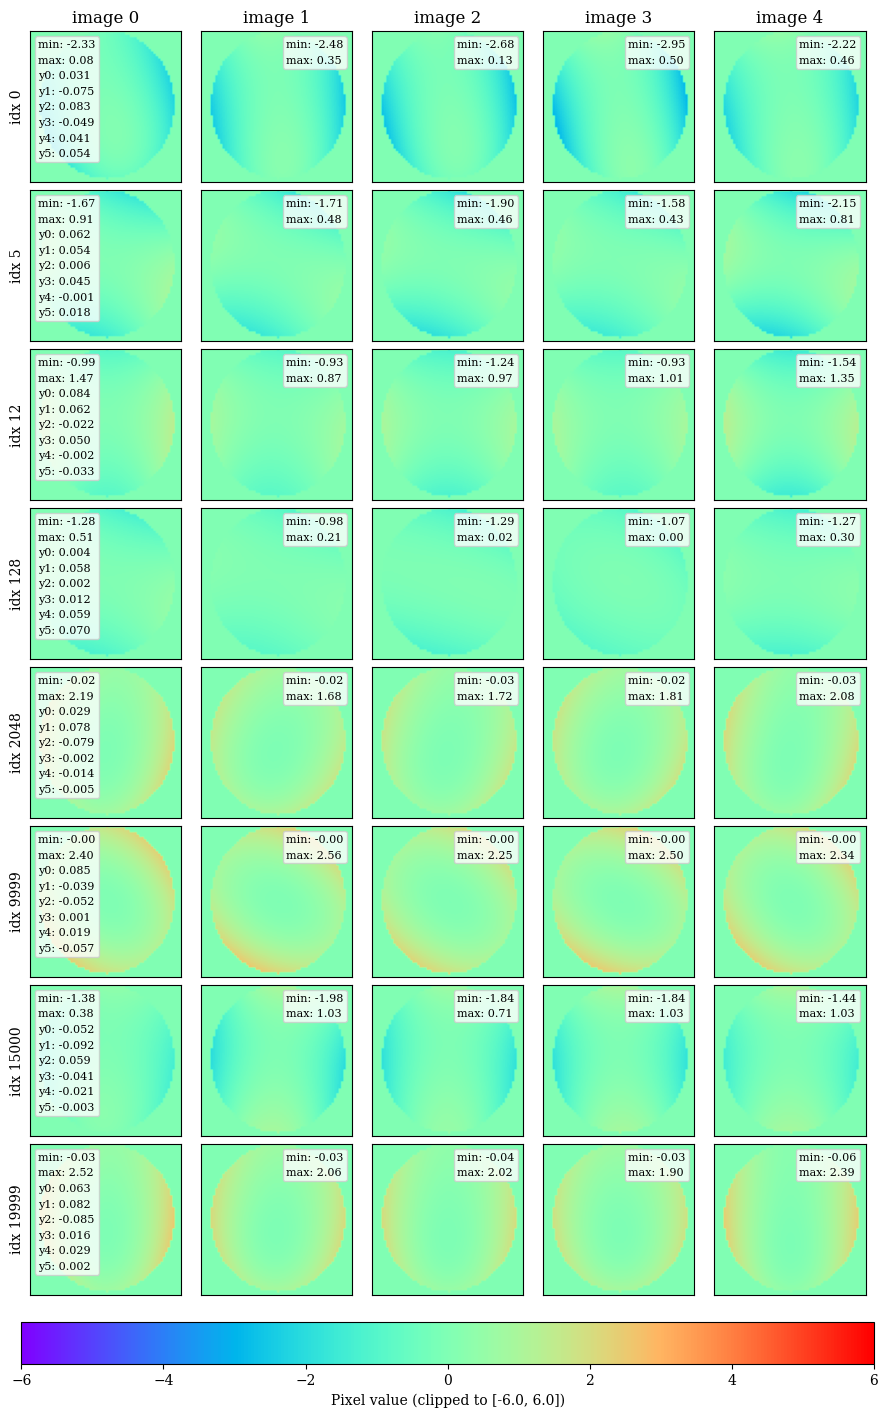

In [14]:
selected_index_list = [0, 5, 12, 128, 2048, 9999, 15000, 19999]
plot_trainingsample(X, y, selected_index_list)

## PyTorching the Model 

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from torchvision import transforms
from torchvision.datasets import CIFAR10

In [16]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [17]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [18]:
!nvidia-smi -L

GPU 0: NVIDIA GeForce RTX 3090 (UUID: GPU-81ef84f4-69df-ce9c-b89c-0b05c8f72ebf)


In [19]:
# Setting the seed
pl.seed_everything(42)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Seed set to 42


#### Checkpoints 

In [20]:
CHECKPOINT_ROOT = '/app/kdrift/decenter+-0.095,tilt+-0.075/pytorch/checkpoints/'

In [21]:
from time import gmtime, strftime

base_name = 'hybrid-ntok256-maxcap6-yrescaled'
#try_name = strftime('%Y.%m.%d_%H:%M', gmtime())
try_name = 'take4'
experiment_name = f"{base_name}_{try_name}"
print("experiment:", experiment_name)
CHECKPOINT_PATH = os.path.join(CHECKPOINT_ROOT, experiment_name)
print("CHECKPOINT_PATH:", CHECKPOINT_PATH)

experiment: hybrid-ntok256-maxcap6-yrescaled_take4
CHECKPOINT_PATH: /app/kdrift/decenter+-0.095,tilt+-0.075/pytorch/checkpoints/hybrid-ntok256-maxcap6-yrescaled_take4


In [22]:
import os
import shutil

CHECKPOINT_PATH = os.path.join(CHECKPOINT_ROOT, experiment_name)

if os.path.exists(CHECKPOINT_PATH):
    print(f"⚠️ Directory exists: {CHECKPOINT_PATH}")
    print("🧹 Removing all contents...")

    # Clear all files/subfolders inside the directory
    for filename in os.listdir(CHECKPOINT_PATH):
        file_path = os.path.join(CHECKPOINT_PATH, filename)
        try:
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.unlink(file_path)
            elif os.path.isdir(file_path):
                shutil.rmtree(file_path)
        except Exception as e:
            print(f"❌ Failed to delete {file_path}: {e}")

    print("✅ Directory has been cleared.")
else:
    os.makedirs(CHECKPOINT_PATH)
    print(f"✅ Directory created: {CHECKPOINT_PATH}")

print(f"📂 Experiment directory is ready: {os.path.abspath(CHECKPOINT_PATH)}")

✅ Directory created: /app/kdrift/decenter+-0.095,tilt+-0.075/pytorch/checkpoints/hybrid-ntok256-maxcap6-yrescaled_take4
📂 Experiment directory is ready: /app/kdrift/decenter+-0.095,tilt+-0.075/pytorch/checkpoints/hybrid-ntok256-maxcap6-yrescaled_take4


### Training Sample

In [23]:
num_samples = len(y)
print(num_samples)

20000


In [24]:
indices=range(num_samples)

In [25]:
X_tr, X_test, y_tr, y_test, tr_indices, test_indices = \
train_test_split(X, y, indices, test_size=0.2, random_state=42)

In [26]:
%%time
X_train, X_val, \
y_train, y_val, \
train_indices, val_indices = \
    train_test_split(
        X_tr,
        y_tr,
        tr_indices,
        test_size=0.2,
        random_state=42
    )

CPU times: user 61.7 ms, sys: 72.6 ms, total: 134 ms
Wall time: 133 ms


### Input Image Normalization by `MAX_CAP=6`

In [27]:
MAX_CAP = 6.0

In [28]:
YL_CAP = 0.095
YH_CAP = 0.075

In [29]:
%%time
# symmetric rescaling per image
X_train_scaled = X_train / MAX_CAP
X_val_scaled = X_val / MAX_CAP
X_test_scaled = X_test / MAX_CAP

CPU times: user 72.8 ms, sys: 92.2 ms, total: 165 ms
Wall time: 163 ms


In [30]:
np_array_info(X_train_scaled)

shape     : (12800, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 262144000
itemsize  : 4 bytes
nbytes    : 1000.00 MB
min / max : -0.9706485271453857 / 0.9772362112998962


In [31]:
np_array_info(X_val_scaled)

shape     : (3200, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 65536000
itemsize  : 4 bytes
nbytes    : 250.00 MB
min / max : -0.919867992401123 / 0.9647147059440613


In [32]:
np_array_info(X_test_scaled)

shape     : (4000, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 81920000
itemsize  : 4 bytes
nbytes    : 312.50 MB
min / max : -0.940781831741333 / 0.9549728035926819


In [33]:
y_train_scaled = np.zeros_like(y_train)
y_val_scaled = np.zeros_like(y_val)
y_test_scaled = np.zeros_like(y_test)

# 채널 0~2
for i in range(3):
    y_train_scaled[:, i] = y_train[:, i]/YL_CAP
    y_val_scaled[:, i] = y_val[:, i]/YL_CAP
    y_test_scaled[:, i] = y_test[:, i]/YL_CAP

# 채널 3~5
for i in range(3, 6):
    y_train_scaled[:, i] = y_train[:, i]/YH_CAP
    y_val_scaled[:, i] = y_val[:, i]/YH_CAP
    y_test_scaled[:, i] = y_test[:, i]/YH_CAP

In [34]:
for i in range(y_train_scaled.shape[1]):
    print(f"channel {i}: min={y_train_scaled[:, i].min()}, \
    max={y_train_scaled[:, i].max()}")

channel 0: min=-1.0,     max=0.9998947381973267
channel 1: min=-0.9996842741966248,     max=0.9996842741966248
channel 2: min=-1.0,     max=0.9998947381973267
channel 3: min=-1.0,     max=0.9998666048049927
channel 4: min=-0.9995999336242676,     max=1.0
channel 5: min=-0.9998666048049927,     max=0.9998666048049927


In [35]:
for i in range(y_val_scaled.shape[1]):
    print(f"channel {i}: min={y_val_scaled[:, i].min()}, \
    max={y_val_scaled[:, i].max()}")

channel 0: min=-0.9996842741966248,     max=0.9981052875518799
channel 1: min=-0.9997894763946533,     max=0.9997894763946533
channel 2: min=-0.9988421201705933,     max=0.9996842741966248
channel 3: min=-0.9998666048049927,     max=0.9990665912628174
channel 4: min=-1.0,     max=0.9997332692146301
channel 5: min=-0.9997332692146301,     max=0.9982665777206421


In [36]:
for i in range(y_test_scaled.shape[1]):
    print(f"channel {i}: min={y_test_scaled[:, i].min()}, \
    max={y_test_scaled[:, i].max()}")

channel 0: min=-0.9995789527893066,     max=0.9996842741966248
channel 1: min=-1.0,     max=0.9996842741966248
channel 2: min=-0.9996842741966248,     max=0.9998947381973267
channel 3: min=-0.9997332692146301,     max=0.9995999336242676
channel 4: min=-0.9994666576385498,     max=0.9997332692146301
channel 5: min=-0.9998666048049927,     max=0.9998666048049927


In [37]:
#plot_trainingsample(X_train_scaled, y,[0,1,2,3,4],pix_min=-1,pix_max=1)

In [38]:
#plot_trainingsample(X_val_scaled, y,[0,1,2,3,4],pix_min=-1,pix_max=1)

In [39]:
#plot_trainingsample(X_test_scaled, y,[0,1,2,3,4],pix_min=-1,pix_max=1)

In [40]:
import matplotlib.pyplot as plt
import numpy as np

def plot_y_histograms_splits(y_train_train, y_train_val, y_test, bins=50):
    """
    y_* shape: (N, 6)
    """

    fig, axes = plt.subplots(2,3, figsize=(9, 6))
    axes = axes.ravel()

    # symmetric range across ALL splits
    all_y = np.concatenate([y_train_train, y_train_val, y_test], axis=0)
    vmin = all_y.min()
    vmax = all_y.max()
    vmax = max(abs(vmin), abs(vmax))
    hist_range = (-vmax, vmax)

    for i in range(6):
        ax = axes[i]

        ax.hist(
            y_train_train[:, i],
            bins=bins,
            range=hist_range,
            density=True,
            color='r',
            alpha=0.2,
            label="train"
        )
        ax.hist(
            y_train_val[:, i],
            bins=bins,
            range=hist_range,
            density=True,
            color='g',
            alpha=0.2,
            label="val"
        )
        ax.hist(
            y_test[:, i],
            bins=bins,
            range=hist_range,
            density=True,
            color='b',
            alpha=0.2,
            label="test"
        )

        ax.axvline(0, color="k", linestyle="--", linewidth=1)
        ax.set_title(f"y{i}")
        ax.set_xlabel("value")
        ax.set_ylabel("density")

        if i == 0:
            ax.legend()

    fig.suptitle("Distribution of y components (train / val / test)", fontsize=13)
    fig.tight_layout()
    plt.show()

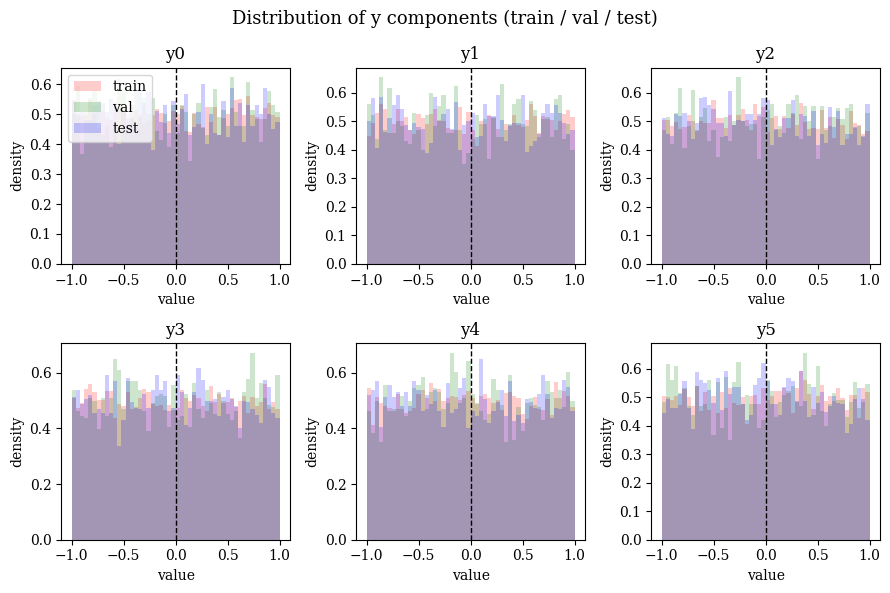

In [41]:
plot_y_histograms_splits(y_train_scaled, y_val_scaled, y_test_scaled)

### DataLoader

In [42]:
from torch.utils.data import Dataset, DataLoader

class NumpyDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx]).float()  # (5,64,64)
        x = x.squeeze(-1) # if (5,64,64,1)
        t = torch.from_numpy(self.y[idx]).float()  # (6,)
        return x, t

In [43]:
train_ds = NumpyDataset(X_train_scaled, y_train_scaled)
val_ds   = NumpyDataset(X_val_scaled, y_val_scaled)
test_ds  = NumpyDataset(X_test_scaled, y_test_scaled)

In [44]:
x0, y0 = train_ds[0]
print(x0.shape)   # torch.Size([5, 64, 64])
print(y0.shape)   # torch.Size([6])

torch.Size([5, 64, 64])
torch.Size([6])


In [45]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader   = DataLoader(test_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

In [46]:
xb, yb = next(iter(train_loader))
print("xb.shape:", xb.shape)
print("yb.shape:", yb.shape)
print("xb.dtype:", xb.dtype)

xb.shape: torch.Size([32, 5, 64, 64])
yb.shape: torch.Size([32, 6])
xb.dtype: torch.float32


## Train vision transformer model

- ViT for 5 channels images

#### Hyperparameters 

In [47]:
MAX_EPOCH = 200
NGRID = 16

In [48]:
import numpy as np
import matplotlib.pyplot as plt

def plot_batch_patch_grid(xb, n_samples=8, ngrid=16, cmap="rainbow",
                                   linewidth=0.5, vmin=None, vmax=None):
    """
    xb: torch.Tensor, shape (B, 5, 64, 64)
    n_samples: number of rows (samples)
    ngrid: number of grid cells per axis (e.g., 16 => patch size 4 for 64x64)
    """
    # tensor -> numpy
    x = xb[:n_samples].detach().cpu().numpy()  # (n_samples, 5, 64, 64)
    n_samples = x.shape[0]
    n_views = x.shape[1]
    H, W = x.shape[2], x.shape[3]

    assert H % ngrid == 0 and W % ngrid == 0, f"H,W must be divisible by ngrid. got {H},{W}, ngrid={ngrid}"
    patch_h = H // ngrid
    patch_w = W // ngrid

    # global color scale (consistent across all panels)
    if vmin is None:
        vmin = float(x.min())
    if vmax is None:
        vmax = float(x.max())

    fig, axes = plt.subplots(
        n_samples, n_views,
        figsize=(n_views * 2.2, n_samples * 2.2),
        constrained_layout=False
    )

    # in case n_samples == 1
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    im = None
    for i in range(n_samples):
        for j in range(n_views):
            ax = axes[i, j]
            img = x[i, j]  # (64,64)

            im = ax.imshow(
                img,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                aspect="equal",
                interpolation="nearest"
            )

            ax.set_xticks([])
            ax.set_yticks([])

            # column titles
            if i == 0:
                ax.set_title(f"ch {j}", fontsize=11)

            # row labels
            if j == 0:
                ax.set_ylabel(f"sample {i}", fontsize=11)

            # draw patch grid boundaries
            for gy in range(0, H + 1, patch_h):
                ax.axhline(gy - 0.5, color="w", linewidth=linewidth, alpha=0.9)
            for gx in range(0, W + 1, patch_w):
                ax.axvline(gx - 0.5, color="w", linewidth=linewidth, alpha=0.9)

    # tighter spacing + bottom colorbar
    fig.subplots_adjust(bottom=0.08, hspace=0.02, wspace=0.02)

    cbar = fig.colorbar(
        im,
        ax=axes,
        orientation="horizontal",
        fraction=0.035,
        pad=0.02
    )
    cbar.set_label("pixel value")

    plt.show()

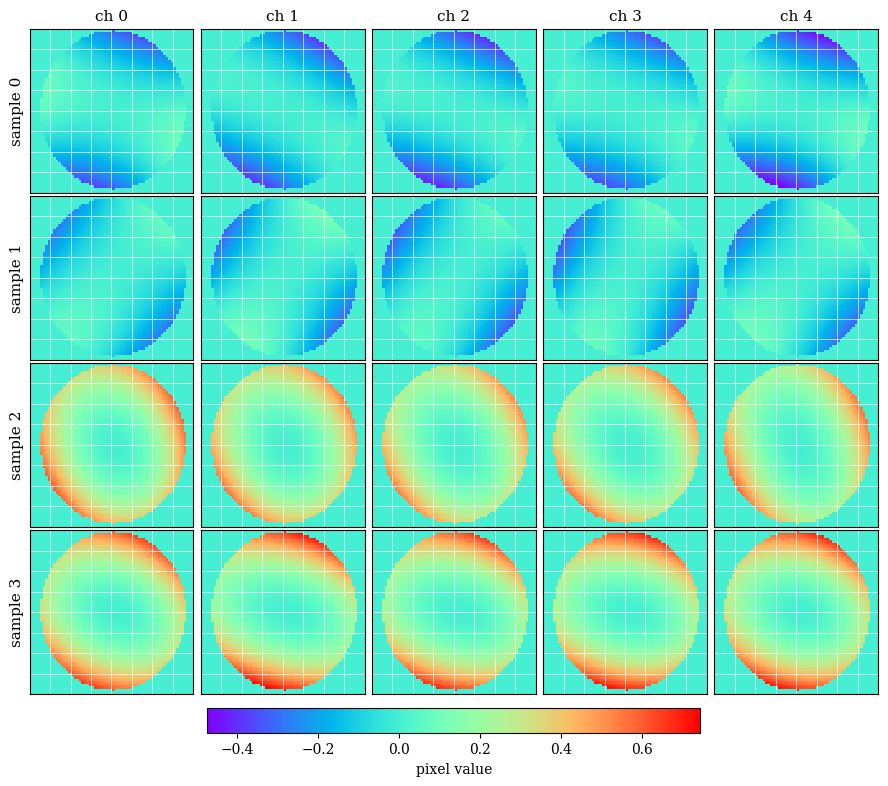

In [49]:
plot_batch_patch_grid(xb, n_samples=4, ngrid=8, cmap="rainbow")

# Vision Transformer Regressor 

- a
- b

In [50]:
class AttentionBlock(nn.Module):
    def __init__(self, embed_dim, hidden_dim, num_heads, dropout=0.0):
        super().__init__()
        self.layer_norm_1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=False)
        self.layer_norm_2 = nn.LayerNorm(embed_dim)
        self.linear = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )
        self.last_attn_weights = None  # 🆕 store attention weights here

    def forward(self, x):
        inp_x = self.layer_norm_1(x)
        #attn_out, attn_weights = self.attn(inp_x, inp_x, inp_x, need_weights=True)
        attn_out, attn_weights = self.attn(inp_x, inp_x, inp_x,need_weights=True, \
                                           average_attn_weights=False)  # 🧠 retain all heads!        
        self.last_attn_weights = attn_weights  # 🆕 save for inspection

        x = x + attn_out
        x = x + self.linear(self.layer_norm_2(x))
        return x

In [51]:
class VisionTransformerRegressorHybrid(nn.Module):
    def __init__(
        self,
        embed_dim=128,
        hidden_dim=256,
        num_channels=5,
        num_heads=4,
        num_layers=4,
        num_outputs=6,
        patch_size=8,
        img_size=64,
        dropout=0.1,
        stem_channels=64,
    ):
        super().__init__()
        assert img_size % patch_size == 0

        self.embed_dim = embed_dim
        self.patch_size = patch_size
        self.img_size = img_size

        # ✅ CNN stem: stride=1로 로컬 특징만 뽑음 (토큰 수는 건드리지 않음)
        # Tanh Activiation Function instead of relu or gelu
        self.stem = nn.Sequential(
            nn.Conv2d(num_channels, stem_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(stem_channels),
            nn.Tanh(),
            nn.Conv2d(stem_channels, stem_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(stem_channels),
            nn.Tanh(),
        )

        # ✅ Conv patch embedding: 여기서 토큰(8x8 grid)을 만듦
        # output: (B, embed_dim, H/P, W/P) = (B, embed_dim, 8, 8)
        self.patch_embed = nn.Conv2d(
            stem_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
            bias=True,
        )

        num_patches = (img_size // patch_size) * (img_size // patch_size)  # 64
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        # 너 노트북에서 쓰는 transformer 블록(AttentionBlock stack) 그대로 쓰면 됨
        #self.transformer = YourTransformerStack(embed_dim, hidden_dim, num_heads, num_layers, dropout)
        # Transformer blocks (same style)
        self.transformer = nn.Sequential(
            *(AttentionBlock(embed_dim, hidden_dim, num_heads, dropout=dropout) for _ in range(num_layers))
        )
 
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_outputs),
        )

    def forward(self, x):
        # (B, 5, 64, 64, 1)도 허용
        if x.ndim == 5 and x.shape[-1] == 1:
            x = x.squeeze(-1)

        # ✅ CNN feature
        x = self.stem(x)                # (B, stem_channels, 64, 64)

        # ✅ tokens 만들기
        x = self.patch_embed(x)         # (B, E, 8, 8)
        x = x.flatten(2).transpose(1, 2)  # (B, 64, E)

        # CLS + pos
        B, T, E = x.shape
        cls = self.cls_token.expand(B, -1, -1)     # (B,1,E)
        x = torch.cat([cls, x], dim=1)             # (B,65,E)
        x = x + self.pos_embedding[:, :T+1]
        x = self.dropout(x)

        # transformer (너 코드가 batch_first=False면 transpose 맞춰)
        x = x.transpose(0, 1)          # (65,B,E)  (네 구현에 맞춤)
        x = self.transformer(x)
        cls_out = x[0]                 # (B,E)

        return self.mlp_head(cls_out)


#### Callbacks 

In [52]:
import pytorch_lightning as pl
import torch
import torch.nn as nn

class LitViTRegressor(pl.LightningModule):
    def __init__(
        self,
        model: nn.Module,
        lr: float = 1e-3,
    ):
        super().__init__()
        self.model = model
        self.loss_fn = nn.L1Loss()
        self.lr = lr

        self.save_hyperparameters(ignore=["model"])

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y)

        self.log(
            "train_loss",
            loss,
            on_epoch=True,
            prog_bar=False,
            sync_dist=False,
        )
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y)

        self.log(
            "val_loss",
            loss,
            on_epoch=True,
            prog_bar=False,
            sync_dist=False,
        )
        return loss
        
    # optimizer settings .. AdamW vs. Adam..?!?
    #def configure_optimizers(self):
    #    return torch.optim.Adam(self.parameters(), lr=self.lr)
    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(),lr=self.lr, \
                                 weight_decay=2e-4)

In [53]:
from pytorch_lightning.callbacks import ModelCheckpoint

checkpoint_callback = ModelCheckpoint(
    dirpath=CHECKPOINT_PATH,
    filename="best-{epoch:03d}-{val_loss:.6f}",
    monitor="val_loss",
    mode="min",
    save_top_k=20,
    save_last=True,
)

In [54]:
import time
import pytorch_lightning as pl

class LossHistoryAndPrinter(pl.Callback):
    def __init__(self, precision=6, print_every_epoch=True):
        self.precision = precision
        self.print_every_epoch = print_every_epoch

        # history
        self.train_loss_by_epoch = {}
        self.val_loss_by_epoch = {}
        self.epoch_times = {}

        # internal
        self._epoch_start_time = None

        # Lightning 버전/설정에 따라 이름이 달라질 수 있어 후보를 둠
        self._train_keys = ("train_loss", "train_loss_epoch")
        self._val_keys   = ("val_loss", "val_loss_epoch")

    def _get_metric_float(self, metrics, keys):
        for k in keys:
            v = metrics.get(k, None)
            if v is not None:
                try:
                    return float(v)
                except TypeError:
                    # just in case it's a tensor-like object
                    return float(v.item())
        return None

    def on_train_epoch_start(self, trainer, pl_module):
        self._epoch_start_time = time.time()

    def on_validation_epoch_end(self, trainer, pl_module):
        # sanity validation은 제외 (훈련 시작 전에 val만 도는 구간)
        if trainer.sanity_checking:
            return

        m = trainer.callback_metrics
        epoch = trainer.current_epoch

        val_loss = self._get_metric_float(m, self._val_keys)
        if val_loss is not None:
            self.val_loss_by_epoch[epoch] = val_loss

    def on_train_epoch_end(self, trainer, pl_module):
        # epoch time
        if self._epoch_start_time is not None:
            epoch_time = time.time() - self._epoch_start_time
            self.epoch_times[trainer.current_epoch] = epoch_time
        else:
            epoch_time = None

        m = trainer.callback_metrics
        epoch = trainer.current_epoch

        # train loss 저장 (키 후보 2개)
        train_loss = self._get_metric_float(m, self._train_keys)
        if train_loss is not None:
            self.train_loss_by_epoch[epoch] = train_loss

        if not self.print_every_epoch:
            return

        # val loss는 validation 훅에서 저장된 값 우선 사용
        val_loss = self.val_loss_by_epoch.get(epoch, None)

        # 출력 (둘 다 없으면 NA로 표시)
        msg = f"Epoch {epoch:03d} | "
        msg += f"train MAE: {('NA' if train_loss is None else f'{train_loss:.{self.precision}f}')} | "
        msg += f"val MAE: {('NA' if val_loss is None else f'{val_loss:.{self.precision}f}')}"

        if epoch_time is not None:
            msg += f" | time: {epoch_time:.2f}s"

        print(msg)

    def as_lists(self):
        # train/val 둘 다 있는 epoch만 정렬해서 반환 (길이 항상 같음)
        epochs = sorted(set(self.train_loss_by_epoch) & set(self.val_loss_by_epoch))
        train = [self.train_loss_by_epoch[e] for e in epochs]
        val = [self.val_loss_by_epoch[e] for e in epochs]
        times = [self.epoch_times.get(e, None) for e in epochs]
        return epochs, train, val, times

In [55]:
import time

class GPUSleepCallback(pl.Callback):
    def __init__(self, sleep_sec=10, every_n_epochs=10):
        self.sleep_sec = sleep_sec
        self.every_n_epochs = every_n_epochs

    def on_train_epoch_end(self, trainer, pl_module):
        stop_modulo = self.every_n_epochs - 1
        if trainer.current_epoch % self.every_n_epochs == stop_modulo:
            print(f"😴 Cooling GPU: sleeping {self.sleep_sec}s after epoch {trainer.current_epoch}")
            time.sleep(self.sleep_sec)

#### Hyper-parameters 64 tokens 

> Default initializing hyper parameters

In [56]:
vit_model = VisionTransformerRegressorHybrid(
    img_size=64,
    patch_size=4,
    num_channels=5,
    num_outputs=6,
    stem_channels=256,
    embed_dim=192,
    hidden_dim=768,
    num_heads=6,
    num_layers=6,
    dropout=0.15,
)

lit_model = LitViTRegressor(
    model=vit_model,
    lr=1e-4,
)

In [58]:
#loss_history_cb = LossHistoryCallback()
#metric_printer_cb = EpochMetricPrinter()
loss_cb = LossHistoryAndPrinter(precision=6)
gpu_sleep_cb = GPUSleepCallback(sleep_sec=20, every_n_epochs=3)

In [59]:
trainer = pl.Trainer(
    max_epochs=2000,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",

    logger=False,                 # 👈 NO logs saved
    enable_progress_bar=False,    # 👈 no tqdm bar
    log_every_n_steps=1,          # 👈 suppress warning

    callbacks=[
        checkpoint_callback,       # (model weights only)
        loss_cb,
        gpu_sleep_cb,
    ],
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [60]:
%%time
trainer.fit(
    lit_model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type                             | Params | Mode  | FLOPs
-----------------------------------------------------------------------------
0 | model   | VisionTransformerRegressorHybrid | 4.1 M  | train | 0    
1 | loss_fn | L1Loss                           | 0      | train | 0    
-----------------------------------------------------------------------------
4.1 M     Trainable params
0         Non-trainable params
4.1 M     Total params
16.437    Total estimated model params size (MB)
81        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 000 | train MAE: 0.312610 | val MAE: 0.212898 | time: 22.57s
Epoch 001 | train MAE: 0.197011 | val MAE: 0.176498 | time: 22.91s
Epoch 002 | train MAE: 0.175466 | val MAE: 0.162154 | time: 23.22s
😴 Cooling GPU: sleeping 20s after epoch 2
Epoch 003 | train MAE: 0.164902 | val MAE: 0.149617 | time: 23.12s
Epoch 004 | train MAE: 0.154893 | val MAE: 0.157024 | time: 23.35s
Epoch 005 | train MAE: 0.155153 | val MAE: 0.146587 | time: 23.51s
😴 Cooling GPU: sleeping 20s after epoch 5
Epoch 006 | train MAE: 0.148863 | val MAE: 0.154229 | time: 23.34s
Epoch 007 | train MAE: 0.147052 | val MAE: 0.145664 | time: 23.78s
Epoch 008 | train MAE: 0.142030 | val MAE: 0.141834 | time: 24.10s
😴 Cooling GPU: sleeping 20s after epoch 8
Epoch 009 | train MAE: 0.139731 | val MAE: 0.138988 | time: 23.56s
Epoch 010 | train MAE: 0.133553 | val MAE: 0.130583 | time: 24.32s
Epoch 011 | train MAE: 0.131176 | val MAE: 0.121720 | time: 24.50s
😴 Cooling GPU: sleeping 20s after epoch 11
Epoch 012 | train MAE: 0.12

`Trainer.fit` stopped: `max_epochs=2000` reached.


Epoch 1999 | train MAE: 0.008486 | val MAE: 0.013749 | time: 27.53s
CPU times: user 8h 6min 12s, sys: 7h 15min 10s, total: 15h 21min 23s
Wall time: 18h 47min 4s


#### Save the training history

In [61]:
CHECKPOINT_PATH

'/app/kdrift/decenter+-0.095,tilt+-0.075/pytorch/checkpoints/hybrid-ntok256-maxcap6-yrescaled_take4'

In [62]:
epochs, train_losses, val_losses, times = loss_cb.as_lists()

print("n_epochs:", len(epochs))
print("n_train_losses:", len(train_losses))
print("n_val_losses:", len(val_losses))
print("train_losses[:3]:", train_losses[:3])
print("val_losses[:3]:", val_losses[:3])

n_epochs: 2000
n_train_losses: 2000
n_val_losses: 2000
train_losses[:3]: [0.3126101791858673, 0.19701099395751953, 0.17546585202217102]
val_losses[:3]: [0.21289773285388947, 0.1764979511499405, 0.16215358674526215]


In [63]:
df = pd.DataFrame({
    "epoch": epochs,
    "train_loss": train_losses,
    "val_loss": val_losses,
})

df.to_csv(f"{CHECKPOINT_PATH}/training_history.csv", index=False)

In [64]:
%ls {CHECKPOINT_PATH}

'best-epoch=1176-val_loss=0.007732.ckpt'
'best-epoch=1186-val_loss=0.007776.ckpt'
'best-epoch=1223-val_loss=0.007628.ckpt'
'best-epoch=1243-val_loss=0.007195.ckpt'
'best-epoch=1380-val_loss=0.007706.ckpt'
'best-epoch=1404-val_loss=0.007815.ckpt'
'best-epoch=1439-val_loss=0.007585.ckpt'
'best-epoch=1448-val_loss=0.007324.ckpt'
'best-epoch=1457-val_loss=0.007205.ckpt'
'best-epoch=1462-val_loss=0.007649.ckpt'
'best-epoch=1469-val_loss=0.007591.ckpt'
'best-epoch=1480-val_loss=0.007675.ckpt'
'best-epoch=1481-val_loss=0.007607.ckpt'
'best-epoch=1543-val_loss=0.007743.ckpt'
'best-epoch=1557-val_loss=0.007457.ckpt'
'best-epoch=1559-val_loss=0.007818.ckpt'
'best-epoch=1572-val_loss=0.007643.ckpt'
'best-epoch=1583-val_loss=0.007782.ckpt'
'best-epoch=1590-val_loss=0.007703.ckpt'
'best-epoch=1602-val_loss=0.007068.ckpt'
 last.ckpt
 training_history.csv


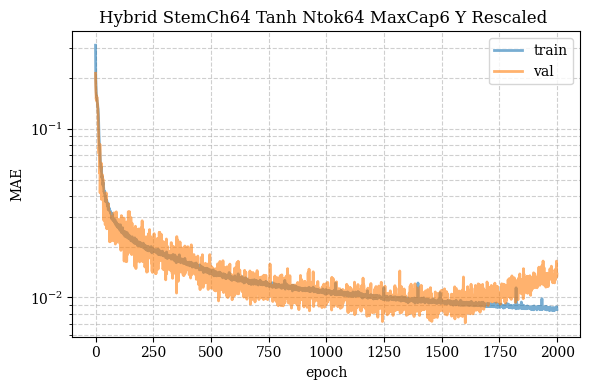

In [65]:
title = "Hybrid StemCh64 Tanh Ntok64 MaxCap6 Y Rescaled "
save_name = "history-hybrid-stemch256-tanh-ntok256-maxcap6-y-rescaled.png"   # 예: .png, .pdf, .jpg

plt.figure(figsize=(6, 4))

plt.plot(epochs, train_losses, label="train", alpha=0.6)
plt.plot(epochs, val_losses, label="val", alpha = 0.6)

plt.xlabel("epoch")
plt.ylabel("MAE")

plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.title(title)
plt.legend()
plt.tight_layout()

plt.savefig(save_name, dpi=300)  # 👈 저장
plt.show()

## Evaluation 

In [66]:
def get_test_predictions(model, test_loader, device):
    model.eval()

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            y_hat = model(xb)          # (B, 6)

            y_true_list.append(yb.cpu().numpy())
            y_pred_list.append(y_hat.cpu().numpy())

    y_true = np.concatenate(y_true_list, axis=0)  # (N_test, 6)
    y_pred = np.concatenate(y_pred_list, axis=0)  # (N_test, 6)

    return y_true, y_pred

In [67]:
%ls {CHECKPOINT_PATH}

'best-epoch=1176-val_loss=0.007732.ckpt'
'best-epoch=1186-val_loss=0.007776.ckpt'
'best-epoch=1223-val_loss=0.007628.ckpt'
'best-epoch=1243-val_loss=0.007195.ckpt'
'best-epoch=1380-val_loss=0.007706.ckpt'
'best-epoch=1404-val_loss=0.007815.ckpt'
'best-epoch=1439-val_loss=0.007585.ckpt'
'best-epoch=1448-val_loss=0.007324.ckpt'
'best-epoch=1457-val_loss=0.007205.ckpt'
'best-epoch=1462-val_loss=0.007649.ckpt'
'best-epoch=1469-val_loss=0.007591.ckpt'
'best-epoch=1480-val_loss=0.007675.ckpt'
'best-epoch=1481-val_loss=0.007607.ckpt'
'best-epoch=1543-val_loss=0.007743.ckpt'
'best-epoch=1557-val_loss=0.007457.ckpt'
'best-epoch=1559-val_loss=0.007818.ckpt'
'best-epoch=1572-val_loss=0.007643.ckpt'
'best-epoch=1583-val_loss=0.007782.ckpt'
'best-epoch=1590-val_loss=0.007703.ckpt'
'best-epoch=1602-val_loss=0.007068.ckpt'
 last.ckpt
 training_history.csv


In [68]:
best_ckpt = f"{CHECKPOINT_PATH}/best-epoch=1602-val_loss=0.007068.ckpt"

vit_model = VisionTransformerRegressorHybrid(
    img_size=64,
    patch_size=4,
    num_channels=5,
    num_outputs=6,
    stem_channels=256,
    embed_dim=192,
    hidden_dim=768,
    num_heads=6,
    num_layers=6,
    dropout=0.15,
)


lit_model = LitViTRegressor.load_from_checkpoint(
    checkpoint_path=best_ckpt,  # ✅ 여기서만 씀
    model=vit_model,            # ✅ 반드시 넘겨야 함
    lr=1e-4,
)

In [69]:
%%time
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
y_test_true, y_test_pred = get_test_predictions(lit_model, test_loader, device)

CPU times: user 2.02 s, sys: 184 ms, total: 2.21 s
Wall time: 2.12 s


In [70]:
print(y_test_true.shape)  # (N_test, 6)
print(y_test_pred.shape)  # (N_test, 6)

(4000, 6)
(4000, 6)


#### Descale the y values 

In [71]:
mae = np.mean(np.abs(y_test_pred - y_test_true), axis=0)
print("Test MAE per y:", mae)
print("Test MAE mean :", mae.mean())

Test MAE per y: [0.00954711 0.00929308 0.00396168 0.00477571 0.00635195 0.00870173]
Test MAE mean : 0.0071052103


In [72]:
YL_CAP, YH_CAP

(0.095, 0.075)

In [73]:
scales = np.array([YL_CAP]*3 + [YH_CAP]*3)  # shape: (6,)

y_test_true_descaled = y_test_true * scales
y_test_pred_descaled = y_test_pred * scales

In [74]:
mae = np.mean(np.abs(y_test_pred_descaled - y_test_true_descaled), axis=0)
print("Test MAE per y:", mae)
print("Test MAE mean :", mae.mean())

Test MAE per y: [0.00090697 0.00088284 0.00037636 0.00035818 0.0004764  0.00065263]
Test MAE mean : 0.0006088968819528298


In [75]:
err = y_test_pred_descaled - y_test_true_descaled
print(err.shape)

(4000, 6)


In [76]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 14,        # 기본 폰트
    "axes.titlesize": 16,   # subplot title
    "axes.labelsize": 14,   # x,y label
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

In [77]:
def plot_error_histograms(err, bins=50):
    """
    err shape: (N, 6)
    """
    fig, axes = plt.subplots(2, 3, figsize=(10, 6))
    axes = axes.ravel()

    # symmetric range for fair comparison
    vmin = err.min()
    vmax = err.max()
    vmax = max(abs(vmin), abs(vmax))
    hist_range = (-vmax, vmax)

    for i in range(6):
        ax = axes[i]

        ax.hist(
            err[:, i],
            bins=bins,
            range=hist_range,
            alpha=0.8
        )

        ax.axvline(0, color="k", linestyle="--", linewidth=1)
        ax.set_title(f"y{i} error")
        ax.set_xlabel("prediction - truth")
        ax.set_ylabel("count")

    fig.suptitle("Test error distribution (y_pred - y_true)", fontsize=12)
    fig.tight_layout()
    plt.show()

In [78]:
#plot_error_histograms(err,bins=200)

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",     # 🔹 whitegrid → white
    context="talk",
    font="serif"
)

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

def plot_error_histograms_seaborn(
    err,
    bins=40,
    xmin=-0.1,
    xmax=0.1,
    save_name="default.pdf",   # 👈 디폴트 파일명
):
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    axes = axes.ravel()

    xlim = (xmin, xmax)

    for i in range(6):
        ax = axes[i]

        sns.histplot(
            err[:, i],
            bins=bins,
            stat="count",
            kde=False,
            color="tab:blue",
            alpha=0.8,
            ax=ax
        )

        ax.axvline(0, color="black", linestyle="--", linewidth=1.5)

        mae  = np.mean(np.abs(err[:, i]))
        rmse = np.sqrt(np.mean(err[:, i] ** 2))

        ax.text(
            0.03, 0.97,
            f"MAE  = {mae:.4f}\nRMSE = {rmse:.4f}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=14,
            bbox=dict(boxstyle="round", fc="white", alpha=0.9)
        )

        ax.set_xlim(xlim)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

        ax.set_title(f"y{i} error", fontsize=16)
        ax.set_xlabel("prediction − truth", fontsize=14)
        ax.set_ylabel("count", fontsize=14)

    fig.suptitle(
        "Test error distribution : Hybrid StemCh256 Tanh NTok256 MaxCap6 Y Rescaled",
        fontsize=20,
        y=0.98
    )

    fig.tight_layout()

    # ✅ PDF 저장 (show 전에!)
    if save_name is not None:
        plt.savefig(save_name, bbox_inches="tight")
        print(f"Saved figure to: {save_name}")

    plt.show()

Saved figure to: hybrid-stemch256-tanh-ntok256-maxcap6-y_rescaled.png


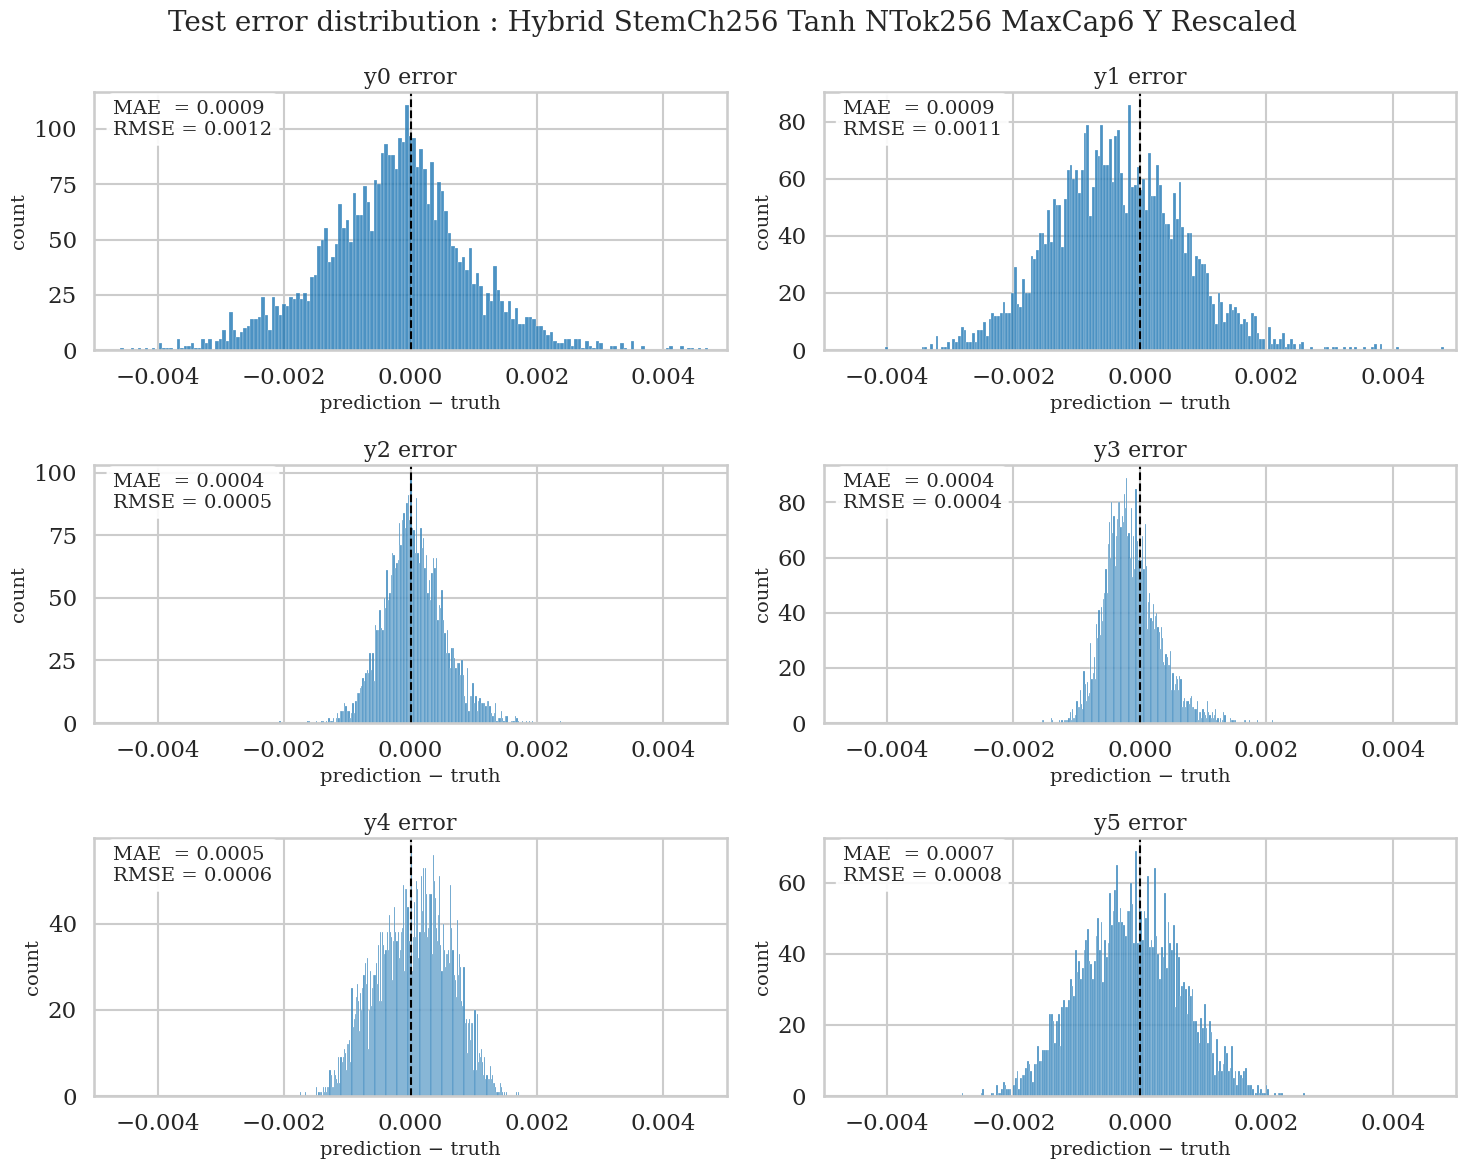

In [82]:
plot_error_histograms_seaborn(err,bins=200,xmin=-0.005,xmax=0.005, \
                             save_name='hybrid-stemch256-tanh-ntok256-maxcap6-y_rescaled.png')